# Detecció d'opinions

Jaume Majó i David Vàzquez

L'objectiu d'aquesta pràctica és implementar un detector d'opinions de l'anglès.  
Per fer-ho, ens basarem amb el corpus movie_reviews ja que tenim 1000 textos amb etiqueta positiva i 1000 textos d'etiqueta negativa.  

## a) Models supervisats

Començarem creant models supervisats que, a partir dels n-grames de paraules del corpus, decidirán si la opinió dels textos son positives o negatives.  

## 1. Importem les llibreries

En primer lloc importem les llibreries necessàries per a la implementeció del detector d'opinions.

In [4]:
# Per preprocessing
import re

# Per corpus, wordnet, sentiwordnet, lesk, tokenize i tagging
import nltk
from nltk.corpus import movie_reviews
from nltk.corpus import sentiwordnet as swn
from nltk.wsd import lesk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet as wn
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('sentiwordnet')

# Per ukb
from textserver import TextServer

# Per extraure n-grames del corpus, analitzar, crear models i visualitzar resultats
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package sentiwordnet to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already u

## 2. Preparem el corpus per modelar

Dividim el corpus en subsets de training (80% del corpus) i test (20% del corpus) i els preprocessem posteriorment en variables diferents ja que els models no supervisats que utilitzarem s'han de tokenitzar.  

En el preprocessat eliminem els números i els guions baixos ja que no aporten res per les opinions dels textos i poden acabar sortint com a part d'una feature al $CountVectorizer$.  

A part del preprocessament que hem fet, també eliminem els stop words (ja que no aporten res per les opinions dels textos) utilitzant el parametre `stop_words = english` de $CountVectorizer$.  

A més, per mantenir la mateixa dimensionalitat sense importar el tamany del corpus, agafarem només els 5000 n-grames mes frequents amb el parametre `max_features = 5000` de $CountVectorizer$.

In [5]:
documents = [(movie_reviews.raw(fileid), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
X = [doc[0] for doc in documents]
y = [doc[1] for doc in documents]

def preprocessing(X):
    for i in range(len(X)):
        cleaned_text = re.sub(r'\d+', '', X[i])  # Eliminar els números
        cleaned_text = re.sub(r'_+', '', cleaned_text)  # Eliminar els _
        X[i] = cleaned_text

# Dividir en entrenament i test (80% entrenament, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_pp = X_train.copy()
preprocessing(X_train_pp)
X_test_pp = X_test.copy()
preprocessing(X_test_pp)

## 3. Entrenament de models supervisats
Per entrenar els models utilitzarem crossvalidation del corpus d'entrenament per trobar amb gridsearch els millors paràmetres, utilitzarem unigrams, bigrams i trigrams de les paraules del corpus com a features.

En aquesta pràctica provarem 4 models. En primer lloc començarem provant mètodes discriminatius com SVM i el perceptró. Després provarem amb mètodes d'ensemble, concretament el model XGBoost. Per últim hem provat amb el model probabilístic Naive Bayes.

### 3.1. SVM

Per al model de svm intentarem trobar el kernel més adecuat així com l'hyperparametre C.

SVM Performance:
              precision    recall  f1-score   support

         neg       0.84      0.82      0.83       199
         pos       0.82      0.84      0.83       201

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



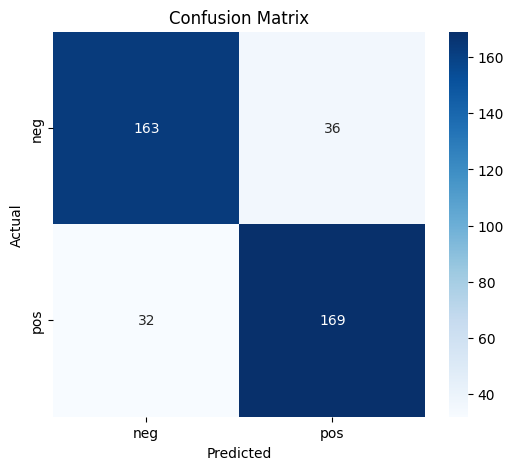

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
"(1, 1)_10_rbf","{'countvectorizer__ngram_range': (1, 1), 'svc_...",1,0.810625,0.023848
"(1, 2)_10_rbf","{'countvectorizer__ngram_range': (1, 2), 'svc_...",2,0.807500,0.020972
"(1, 3)_10_rbf","{'countvectorizer__ngram_range': (1, 3), 'svc_...",2,0.807500,0.020972
"(1, 2)_1_rbf","{'countvectorizer__ngram_range': (1, 2), 'svc_...",4,0.805625,0.023502
"(1, 3)_1_rbf","{'countvectorizer__ngram_range': (1, 3), 'svc_...",5,0.803750,0.023251
"(1, 1)_1_rbf","{'countvectorizer__ngram_range': (1, 1), 'svc_...",6,0.803750,0.022827
"(1, 1)_1_linear","{'countvectorizer__ngram_range': (1, 1), 'svc_...",7,0.800000,0.013835
"(1, 1)_10_linear","{'countvectorizer__ngram_range': (1, 1), 'svc_...",7,0.800000,0.013835
"(1, 1)_0.1_linear","{'countvectorizer__ngram_range': (1, 1), 'svc_...",9,0.798750,0.017298


In [6]:
pipeline = make_pipeline(CountVectorizer(stop_words='english', max_features=5000), SVC())

param_grid = {
    'countvectorizer__ngram_range': [(1,1), (1,2), (1,3)],
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_svm = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

gs_svm.fit(X_train, y_train)

y_pred = gs_svm.predict(X_test)

print("SVM Performance:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gs_svm.classes_, yticklabels=gs_svm.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_svm.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

### 3.2. Perceptron

Per el perceptró veurem si es millor regularitzar o no, buscant el hiperparàmetre de regularització alpha més adecuat.  
En aquest cas que no triga gaire hem deixat el perceptró sense regularització dintre del gridsearch encara que això faci que executi 3 vegades el mateix (un per cada alpha diferent).

Perceptron Performance:
              precision    recall  f1-score   support

         neg       0.80      0.79      0.80       199
         pos       0.80      0.81      0.80       201

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



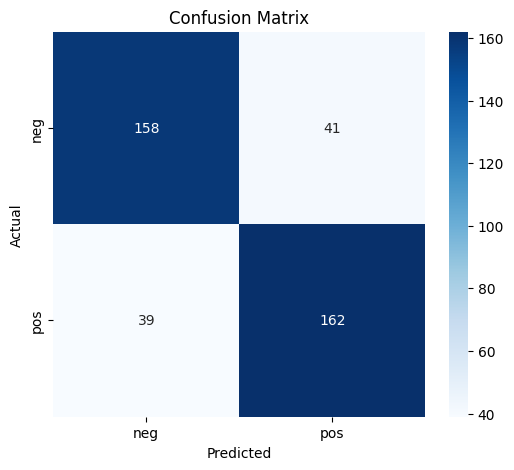

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
"(1, 2)_0.0001_l1","{'countvectorizer__ngram_range': (1, 2), 'perc...",1,0.808125,0.011957
"(1, 3)_0.01_None","{'countvectorizer__ngram_range': (1, 3), 'perc...",2,0.805000,0.016008
"(1, 3)_0.001_None","{'countvectorizer__ngram_range': (1, 3), 'perc...",2,0.805000,0.016008
"(1, 3)_0.0001_None","{'countvectorizer__ngram_range': (1, 3), 'perc...",2,0.805000,0.016008
"(1, 1)_0.0001_l1","{'countvectorizer__ngram_range': (1, 1), 'perc...",5,0.802500,0.011250
"(1, 1)_0.01_None","{'countvectorizer__ngram_range': (1, 1), 'perc...",6,0.799375,0.020767
"(1, 1)_0.001_None","{'countvectorizer__ngram_range': (1, 1), 'perc...",6,0.799375,0.020767
"(1, 1)_0.0001_None","{'countvectorizer__ngram_range': (1, 1), 'perc...",6,0.799375,0.020767
"(1, 2)_0.0001_None","{'countvectorizer__ngram_range': (1, 2), 'perc...",9,0.798750,0.023602


In [7]:
pipeline = make_pipeline(CountVectorizer(stop_words='english', max_features=5000), Perceptron())

param_grid = {
    'countvectorizer__ngram_range': [(1,1), (1,2), (1,3)],
    'perceptron__penalty': [None, 'l2', 'l1'],
    'perceptron__alpha': [0.0001, 0.001, 0.01],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_per = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

gs_per.fit(X_train_pp, y_train)

y_pred = gs_per.predict(X_test_pp)

print("Perceptron Performance:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gs_per.classes_, yticklabels=gs_per.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_per.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

### 3.3. XGBoost

Per el model de xgboost buscarem el nombre d'arbres més adecuat, la seva profunditat, el learning rate i la mida de les features per arbre.

XGBoost Performance:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       199
           1       0.86      0.83      0.85       201

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



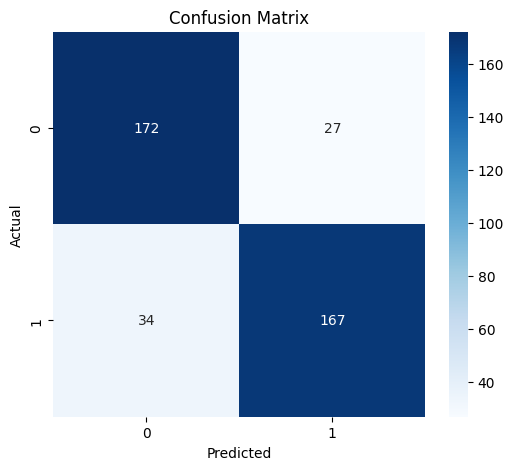

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
"(1, 1)_0.1_3_200_0.8","{'countvectorizer__ngram_range': (1, 1), 'xgbc...",1,0.815625,0.018854
"(1, 1)_0.05_6_200_0.8","{'countvectorizer__ngram_range': (1, 1), 'xgbc...",2,0.811250,0.013050
"(1, 2)_0.1_10_200_0.8","{'countvectorizer__ngram_range': (1, 2), 'xgbc...",3,0.811250,0.014737
"(1, 3)_0.1_10_200_0.8","{'countvectorizer__ngram_range': (1, 3), 'xgbc...",4,0.810000,0.013463
"(1, 3)_0.1_6_200_1.0","{'countvectorizer__ngram_range': (1, 3), 'xgbc...",5,0.808750,0.020672
...,...,...,...,...
"(1, 2)_0.01_3_100_0.8","{'countvectorizer__ngram_range': (1, 2), 'xgbc...",103,0.688750,0.026413
"(1, 3)_0.01_3_100_0.8","{'countvectorizer__ngram_range': (1, 3), 'xgbc...",103,0.688750,0.026413
"(1, 2)_0.01_3_100_1.0","{'countvectorizer__ngram_range': (1, 2), 'xgbc...",106,0.683125,0.019823


In [8]:
pipeline = make_pipeline(CountVectorizer(stop_words='english', max_features=5000), XGBClassifier(eval_metric='logloss'))

param_grid = {
    'countvectorizer__ngram_range': [(1,1), (1,2), (1,3)],
    'xgbclassifier__n_estimators': [100, 200],
    'xgbclassifier__max_depth': [3, 6, 10],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__subsample': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_xgb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
gs_xgb.fit(X_train_pp, y_train_encoded)

y_test_encoded = le.fit_transform(y_test)
y_pred = gs_xgb.predict(X_test_pp)

print("XGBoost Performance:")
print(classification_report(y_test_encoded, y_pred))

cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gs_xgb.classes_, yticklabels=gs_xgb.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_xgb.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

### 3.4 Naive Bayes

Per aquest últim model, més enllà del n-grama usat, farem el GridSearch per trobar la millor alpha (suavitzat de Laplace) i fit_prior (en el nostre cas com que les dues classes surten el mateix nombre de vegades no importa si es True o False, es a dir, o podem treure pero ho deixem per si es canviessin les dades d'entrenament en un futur) que indica si s'aprenen les probabilitats a priori de cada classe o no.

Naive Bayes Performance:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       199
           1       0.83      0.78      0.80       201

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



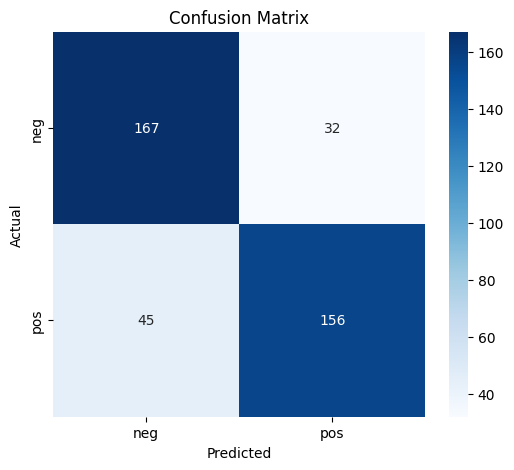

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
"(1, 3)_0.5_True","{'countvectorizer__ngram_range': (1, 3), 'mult...",1,0.798750,0.009396
"(1, 3)_0.5_False","{'countvectorizer__ngram_range': (1, 3), 'mult...",1,0.798750,0.009396
"(1, 3)_1.0_True","{'countvectorizer__ngram_range': (1, 3), 'mult...",1,0.798750,0.011285
"(1, 3)_1.0_False","{'countvectorizer__ngram_range': (1, 3), 'mult...",1,0.798750,0.011285
"(1, 3)_2.0_True","{'countvectorizer__ngram_range': (1, 3), 'mult...",5,0.798125,0.013919
"(1, 3)_2.0_False","{'countvectorizer__ngram_range': (1, 3), 'mult...",5,0.798125,0.013919
"(1, 2)_2.0_True","{'countvectorizer__ngram_range': (1, 2), 'mult...",5,0.798125,0.008970
"(1, 2)_2.0_False","{'countvectorizer__ngram_range': (1, 2), 'mult...",5,0.798125,0.008970
"(1, 2)_1.0_False","{'countvectorizer__ngram_range': (1, 2), 'mult...",9,0.796875,0.005229


In [9]:
from sklearn.naive_bayes import MultinomialNB

pipeline = make_pipeline(CountVectorizer(stop_words='english', max_features=5000), MultinomialNB())

param_grid = {
    'countvectorizer__ngram_range': [(1,1), (1,2), (1,3)],
    'multinomialnb__alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
    'multinomialnb__fit_prior': [True, False]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_nb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
gs_nb.fit(X_train_pp, y_train_encoded)

y_test_encoded = le.transform(y_test)  # transform en lugar de fit_transform
y_pred = gs_nb.predict(X_test_pp)

print("Naive Bayes Performance:")
print(classification_report(y_test_encoded, y_pred))

cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_nb.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

### 3.5 Anàlisis de resultats

Les millors precisions obtingudes per cada tipus de model són les següents en el conjunt de test:
- `SVM`: 0.83	
- `Perceptró`: 0.80
- `XGBoost`: 0.85
- `Naive Bayes`: 0.81

En general, veiem que tots els models en general acaben utilitzant unigrames, a excepció del perceptró (que el millor model utilitza unigrames i bigrames) i `SVM` (que tant per unigrames com unigrames i bigrames obté la mateixa precisió).

Tot i que en general surt una precisió bastant similar en tots els models destaquen `SVM` i `XGBoost`. Com a model candidat dels supervistats ens quedarem amb `XGBoost`. Tot i això, deixarem el model `SVM` com a alternativa més senzilla i interpretable.

## b) Models no supervisats

Per als models no supervisats tokenitzem els textos per poder donar-lis les tags i els synsets més adecuats per a cada paraula segons el context en el que es troben.  

Un cop tenim els synsets i tags per a cada paraula podrem utilitzar el $SentiWordnet$ per poder donar-li un valor d'opinió que combinats escollirán la positivitat i negativitat del text senser.

In [10]:
wnl = nltk.stem.WordNetLemmatizer()
d = {'NN': 'n', 'NNS': 'n', 
       'JJ': 'a', 'JJR': 'a', 'JJS': 'a', 
       'VB': 'v', 'VBD': 'v', 'VBG': 'v', 'VBN': 'v', 'VBP': 'v', 'VBZ': 'v', 
       'RB': 'r', 'RBR': 'r', 'RBS': 'r'}

def lemmatize(p):
  if p[1] in d:
    return wnl.lemmatize(p[0], pos=d[p[1]]), d[p[1]]
  return p[0], None

def search_equal(res_search, search_term, i):
    while i < len(res_search):
        if search_term == res_search[i][0]:
            return True
        i += 1
    return False

def print_synsets_side_by_side(frase, resultat_lesk, resultat_ukb):
  print(frase)
  i = 0
  j = 0
  while i < len(resultat_lesk):
      k = j
      print(f"lesk: {resultat_lesk[i][0]} {resultat_lesk[i][1]} {resultat_lesk[i][2]}", end=" " if k < len(resultat_ukb) else "\n")
      printed = False
      while k < len(resultat_ukb):
          if resultat_lesk[i][0] == resultat_ukb[k][0]:
              printed = True
              print(f"{' ' * (150 - len(resultat_lesk[i][0]) - len(resultat_lesk[i][1]) - len(resultat_lesk[i][2]))} ukb: {resultat_ukb[k][0]} {resultat_ukb[k][1]} {resultat_ukb[k][2]}")
              k += 1
              break
          else:
              if search_equal(resultat_lesk, resultat_ukb[k][0], i):
                  if not printed:
                      print()
                  break
              printed = True
              print(f"\n{' '*159} ukb: {resultat_ukb[k][0]} {resultat_ukb[k][1]} {resultat_ukb[k][2]}")
              k += 1
      
      j = k
      i += 1

  while j < len(resultat_ukb):
      print(f"{' ' * 150} ukb: {resultat_ukb[j][0]} {resultat_ukb[j][1]} {resultat_ukb[j][2]}")
      j += 1

## 4. Comparació UKB vs Lesk

Per saber quin és el millor mètode de desambiguació del sentit de les paraules (es a dir, d'assignació de synsets als tokens) compararem els dos mètodes de `UKB` i `lesk`.  

Mentres que el `lesk` utilitza un senzill però efectiu compteig del nombre de paraules que surten tant al context com a la definició del synset, el `UKB` utilitza un mètode més sofisticat realitzant un algoritme de PageRank per escollir el node del graph més probable i per tant obtenir el synset adecuat.  

Tenint en compte la diferència de complexitat tindria sentit que el `UKB` fos el millor mètode, per asegurar-nos agafarem una mostra de text i compararem els synsets escollits per cadascun.

In [ ]:
frase = movie_reviews.raw(movie_reviews.fileids('pos')[:2][0]).split("\n")[0] # UKB
ts = TextServer(user, password, 'senses')
synset_table = ts.senses(frase)
resultat_ukb = []
for frase_synset in synset_table:
    for synset in frase_synset:
        if synset[4] != 'N/A':
            syn = wn.synset_from_pos_and_offset(synset[4][-1], int(synset[4][:-2]))
            resultat_ukb.append((synset[0],syn.name(), syn.definition()))

In [12]:
words = nltk.word_tokenize(frase, language='english') # Lesk
tags = nltk.pos_tag(words)
resultat_lesk = []
for pair in tags:
    lem = lemmatize(pair)
    if lem[1] != None:
        synset = nltk.wsd.lesk(frase, *lem)
        if synset:
            resultat_lesk.append((pair[0],synset.name(), synset.definition()))
        else:
            resultat_lesk.append((pair[0],"", ""))

In [13]:
print_synsets_side_by_side(frase, resultat_lesk=resultat_lesk, resultat_ukb=resultat_ukb)

films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
lesk: films movie.n.01 a form of entertainment that enacts a story by sound and a sequence of images giving the illusion of continuous movement                 ukb: films movie.n.01 a form of entertainment that enacts a story by sound and a sequence of images giving the illusion of continuous movement
lesk: adapted adapt.v.01 make fit for, or change to suit a new purpose                                                                                          ukb: adapted adapt.v.01 make fit for, or change to suit a new purpose
lesk: comic comic.a.02 of or relating to or characteristic of comedy                                                                                            ukb: comic amusing.s.02 arousing or prov

D'aquesta mostra hem vist els següents resultats:
Els dos mètodes coincideixen en unes 6 ($films$, $adapted$, $spawn$, $crowd$, $really$ i $batman$) paraules, de les quals $batman$ donen una definició inadecuada conjuntament.  

A més, donen per unes altres 4 ($success$, $world$, $never$, $hell$) paraules definicions molt semblants o similarment correctes i per a 2 ($have$, $had$) paraules definicions similarment incorrectes.  

`Lesk`, per a 3 paraules ($comic$ (2 vegades), $plenty$ (falta a `UKB`), $superman$) ha escollit definicions millors a `UKB`.  

Mentres que `UKB` per a 4 paraules ($books$ (2 vegades), $kids$, $ghost$ (falta a `lesk`), $is$ (falta a `lesk`), $been$) ha escollit definicions millors a `lesk`.  

Finalment, els dos mètodes s'han equivocat 1 ($casper$ (`lesk`), $there$ (`UKB`)) vegada en escollir un synset per una paraula que l'altre mètode no ha escollit.  

Veient els resultats (i sabent que estem utilitzant una mostra molt petita) podem veure que encara que `UKB` sembla donar millors resultats la diferència no sembla ser massa gran. Així que utilitzarem el mètode `lesk` per fer els models no supervisats ja que aquest es més accesible desde python.  

## 5. Càlcul de l'opinió

Per calcular l'opinió dels textos analitzarem els synsets que ens dona el mètode `lesk` per a cada paraula, utilitzant $SentiWordnet$ per saber el seu score positiu i negatiu.  

Amb aquests valors hem creat dos mètodes per classificar els textos, `opinio_diferencia` resta de l'score positiu el negatiu per trobar la diferència (0 si no hi ha synset) i sumar-la a un valor conjunt $sentiment_score$, si al final de tot aquest $sentiment_score$ es positiu (o zero ja que volem un classificador de positiu i negatiu) el text el classificarem com a positiu, i viceversa.
L'altre mètode és `opinio_diferencia_cuadrada` que en comptes de fer la diferència dels scores ho fa dels seus quadrats. La idea darrere aquest últim métode és intentar donar encara més pes aquelles paraules que mostren una valor molt positiu (o negatiu) i desvaluar els que tinguin molt poc.

A més, hem implementat una llista `accepted` per escollir quin tipus de paraules (adjectius, noms, verbs i adverbis) aporten valor a $sentiment\_score$ i un filtre per eliminar valors menors a cert llindar.

In [14]:
def opinio_diferencia(synset):
    if synset:
        senti_synset = swn.senti_synset(synset.name())
        return senti_synset.pos_score() - senti_synset.neg_score()
    return 0.0  # Si no trobem cap synset, retornem un sentiment neutral

def opinio_diferencia_cuadrada(synset):
    if synset:
        senti_synset = swn.senti_synset(synset.name())
        return senti_synset.pos_score()**2 - senti_synset.neg_score()**2
    return 0.0  # Si no trobem cap synset, retornem un sentiment neutral

def calcular_opinio_text(text, accepted = ["n", "v", "r", "a"], calc_opinio = opinio_diferencia, filtre = 0):
    sentiment_score = 0.0
    
    words = nltk.word_tokenize(text, language='english')
    tags = nltk.pos_tag(words)

    if filtre > 0:
        for pair in tags:
            lem = lemmatize(pair)
            if lem[1] != None and lem[1] in accepted:
                synset = nltk.wsd.lesk(text, *lem)
                c = calc_opinio(synset)
                sentiment_score += c if abs(c) >= filtre else 0
    else:
        for pair in tags:
            lem = lemmatize(pair)
            if lem[1] != None and lem[1] in accepted:
                synset = nltk.wsd.lesk(text, *lem)
                sentiment_score += calc_opinio(synset)

    return "pos" if sentiment_score >= 0 else "neg"


## 6. Probar els models per a escollir el millor

Utilitzarem el conjunt de training per escollir el millor model segons si utilitzem adjectius, noms i adjectius, noms i adjectius i adverbis o noms i adjectius i adverbis i verbs, i també el mètode de càlcul de l'opinió que utilitzem, `opinio_diferencia` o `opinio_diferencia_cuadrada` i amb o sense filtre (0.25 per `opinio_diferencia` i 0.1 per `opinio_diferencia_cuadrada` ja que els valors son més petits [0-0.5]).

### 6.1. Adjectius

In [15]:
print("Adjectius:")

y_pred = [calcular_opinio_text(text, ["a"], calc_opinio = opinio_diferencia) for text in X_train]
print("Opinio diferencia:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["a"], calc_opinio = opinio_diferencia_cuadrada) for text in X_train]
print("Opinio diferencia cuadrada:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["a"], calc_opinio = opinio_diferencia, filtre = 0.25) for text in X_train]
print("Opinio diferencia amb filtre de 0.25:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["a"], calc_opinio = opinio_diferencia_cuadrada, filtre = 0.1) for text in X_train]
print("Opinio diferencia cuadrada amb filtre de 0.1:")
print(classification_report(y_train, y_pred))

Adjectius:
Opinio diferencia:
              precision    recall  f1-score   support

         neg       0.65      0.49      0.55       801
         pos       0.59      0.73      0.65       799

    accuracy                           0.61      1600
   macro avg       0.62      0.61      0.60      1600
weighted avg       0.62      0.61      0.60      1600

Opinio diferencia cuadrada:
              precision    recall  f1-score   support

         neg       0.63      0.54      0.58       801
         pos       0.59      0.67      0.63       799

    accuracy                           0.61      1600
   macro avg       0.61      0.61      0.61      1600
weighted avg       0.61      0.61      0.61      1600

Opinio diferencia amb filtre de 0.25:
              precision    recall  f1-score   support

         neg       0.64      0.54      0.58       801
         pos       0.60      0.70      0.64       799

    accuracy                           0.62      1600
   macro avg       0.62      0.6

### 6.2. Noms, adjectius i adverbis

In [16]:
print("Noms, adjectius i adverbis:")

y_pred = [calcular_opinio_text(text, ["n", "a", "r"], calc_opinio = opinio_diferencia) for text in X_train]
print("Opinio diferencia:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r"], calc_opinio = opinio_diferencia_cuadrada) for text in X_train]
print("Opinio diferencia cuadrada:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r"], calc_opinio = opinio_diferencia, filtre = 0.25) for text in X_train]
print("Opinio diferencia amb filtre de 0.25:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r"], calc_opinio = opinio_diferencia_cuadrada, filtre = 0.1) for text in X_train]
print("Opinio diferencia cuadrada amb filtre de 0.1:")
print(classification_report(y_train, y_pred))

Noms, adjectius i adverbis:
Opinio diferencia:
              precision    recall  f1-score   support

         neg       0.60      0.58      0.59       801
         pos       0.59      0.62      0.61       799

    accuracy                           0.60      1600
   macro avg       0.60      0.60      0.60      1600
weighted avg       0.60      0.60      0.60      1600

Opinio diferencia cuadrada:
              precision    recall  f1-score   support

         neg       0.59      0.68      0.63       801
         pos       0.62      0.52      0.57       799

    accuracy                           0.60      1600
   macro avg       0.61      0.60      0.60      1600
weighted avg       0.61      0.60      0.60      1600

Opinio diferencia amb filtre de 0.25:
              precision    recall  f1-score   support

         neg       0.60      0.64      0.62       801
         pos       0.61      0.57      0.59       799

    accuracy                           0.60      1600
   macro avg   

### 6.3. Noms, adjectius, adverbis i verbs

In [17]:
print("Noms, adjectius, adverbis i verbs:")

y_pred = [calcular_opinio_text(text, ["n", "a", "r", "v"], calc_opinio = opinio_diferencia) for text in X_train]
print("Opinio diferencia:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r", "v"], calc_opinio = opinio_diferencia_cuadrada) for text in X_train]
print("Opinio diferencia cuadrada:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r", "v"], calc_opinio = opinio_diferencia, filtre = 0.25) for text in X_train]
print("Opinio diferencia amb filtre de 0.25:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r", "v"], calc_opinio = opinio_diferencia_cuadrada, filtre = 0.1) for text in X_train]
print("Opinio diferencia cuadrada amb filtre de 0.1:")
print(classification_report(y_train, y_pred))

Noms, adjectius, adverbis i verbs:
Opinio diferencia:
              precision    recall  f1-score   support

         neg       0.68      0.17      0.28       801
         pos       0.53      0.92      0.67       799

    accuracy                           0.55      1600
   macro avg       0.60      0.55      0.47      1600
weighted avg       0.60      0.55      0.47      1600

Opinio diferencia cuadrada:
              precision    recall  f1-score   support

         neg       0.65      0.45      0.53       801
         pos       0.58      0.76      0.66       799

    accuracy                           0.61      1600
   macro avg       0.62      0.61      0.60      1600
weighted avg       0.62      0.61      0.60      1600

Opinio diferencia amb filtre de 0.25:
              precision    recall  f1-score   support

         neg       0.64      0.42      0.51       801
         pos       0.57      0.77      0.65       799

    accuracy                           0.59      1600
   macro

## 7. Executar els models en el conjunt de test

Utilitzarem el mètode de càlcul de `opinio_diferencia_cuadrada` ja que dona valors més consistents, sense filtre ja que no hi ha gran diferència entre els dos.

### 7.1. Adjectius

Adjectius:
              precision    recall  f1-score   support

         neg       0.65      0.54      0.59       199
         pos       0.61      0.72      0.66       201

    accuracy                           0.63       400
   macro avg       0.63      0.63      0.62       400
weighted avg       0.63      0.63      0.62       400



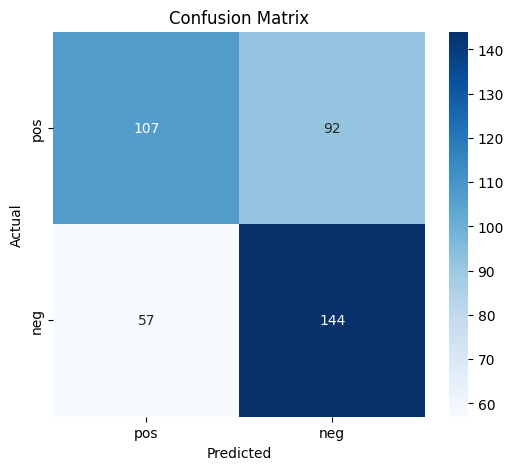

In [21]:
y_pred = [calcular_opinio_text(text, ["a"], calc_opinio = opinio_diferencia_cuadrada) for text in X_test]

print("Adjectius:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_pred))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 7.2. Noms, adjectius i adverbis

Noms, adjectius i adverbis:
              precision    recall  f1-score   support

         neg       0.62      0.68      0.65       199
         pos       0.65      0.59      0.62       201

    accuracy                           0.64       400
   macro avg       0.64      0.64      0.64       400
weighted avg       0.64      0.64      0.64       400



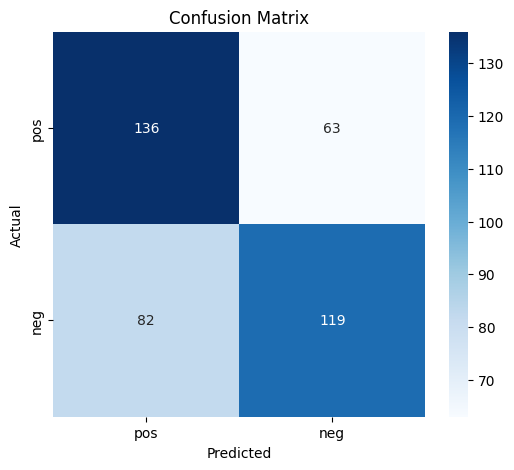

In [22]:
y_pred = [calcular_opinio_text(text, ["n", "a", "r"], calc_opinio = opinio_diferencia_cuadrada) for text in X_test]

print("Noms, adjectius i adverbis:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_pred))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 7.3. Noms, adjectius, adverbis i verbs

Noms, adjectius, adverbis i verbs:
              precision    recall  f1-score   support

         neg       0.69      0.46      0.55       199
         pos       0.60      0.80      0.68       201

    accuracy                           0.63       400
   macro avg       0.64      0.63      0.62       400
weighted avg       0.64      0.63      0.62       400



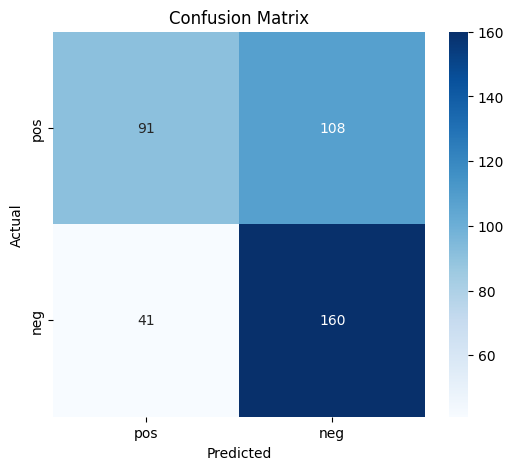

In [23]:
y_pred = [calcular_opinio_text(text, ["n", "a", "r", "v"], calc_opinio = opinio_diferencia_cuadrada) for text in X_test]

print("Noms, adjectius, adverbis i verbs:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_pred))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 7.4 Anàlisi de resultats

Les precisions obtingudes han estat:
- Adjectius:                          0.63
- Noms, adjectius, adverbis:          0.64
- Noms, adjectius, adverbis, verbs:   0.63

Veiem doncs que el model que ens aporta millors resultats és el que té en compte els noms, adjectius i adverbis, aquest model utilitza el mètode `opinio_diferencia_cuadrada` sense filtre. La resta de models, tenen precisions similars, però podem veure que introduir els verbs pitjors resultats degut a que aquests probablement introdueixen soroll ja que no solen donar cap tipus d'opinió.

## 8. Resultats finals

Comparant el millor model supervisat (`XGBoost` amb una precisió de 0.85) amb el millor model no supervisat (basat en noms, adjectius, adverbis, 0.64), observem que la diferència de precisió es substancial. Per aquest motiu, doncs, el model escollit és `XGBoost`.

És obvi que els models supervisats obtenen millors resultats ja que s'aprofiten de l'entrenament amb dades ja etiquetades. D'altra banda, els models no supervisats no requereix dades etiquetades per ser entrenat, cosa que el fa útil en altres contextos on no es disposa d'un conjunt d'entrenament.